In [1]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing  import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
xr  = np.random.rand(200, 1)
yr  = np.random.rand(200, 1)

In [3]:
print(xr)
print(yr)

[[0.55691538]
 [0.54233089]
 [0.88627618]
 [0.66711312]
 [0.95856208]
 [0.40825194]
 [0.57736519]
 [0.11462822]
 [0.5007404 ]
 [0.00420636]
 [0.11653966]
 [0.39871556]
 [0.85849465]
 [0.09883664]
 [0.31088368]
 [0.39654534]
 [0.35185523]
 [0.39991701]
 [0.90629913]
 [0.68102209]
 [0.80006588]
 [0.1847097 ]
 [0.03218369]
 [0.69346327]
 [0.91008548]
 [0.17791436]
 [0.66335833]
 [0.8630832 ]
 [0.17789096]
 [0.84486701]
 [0.68558689]
 [0.75084454]
 [0.09460474]
 [0.82804377]
 [0.80430986]
 [0.60467874]
 [0.09685345]
 [0.07642109]
 [0.05022213]
 [0.72895483]
 [0.49082338]
 [0.96654705]
 [0.02014111]
 [0.43689094]
 [0.66671247]
 [0.33024142]
 [0.60547116]
 [0.09108794]
 [0.52593822]
 [0.90520275]
 [0.1578693 ]
 [0.2954273 ]
 [0.72576334]
 [0.35562728]
 [0.89583767]
 [0.14066516]
 [0.10929389]
 [0.57928067]
 [0.60423793]
 [0.52005816]
 [0.62492053]
 [0.10335422]
 [0.76385221]
 [0.86717304]
 [0.54510925]
 [0.60168499]
 [0.58201957]
 [0.41867369]
 [0.52004556]
 [0.85043041]
 [0.46322836]
 [0.35

In [4]:
# x = 6  * xr - 3
# y = 0.8 * x**2 + 0.9* x + 2 +  yr

x = 6* xr - 3
y = 0.8* x**2 + 0.9*x + 2 +  yr

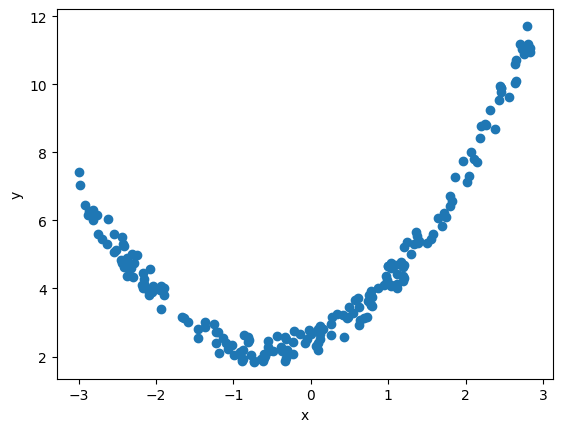

In [5]:
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state= 2)  

In [7]:
lr = LinearRegression()
lr.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
ypred = lr.predict(xtest)

In [9]:
r2_score(ytest, ypred)

0.2308206452948306

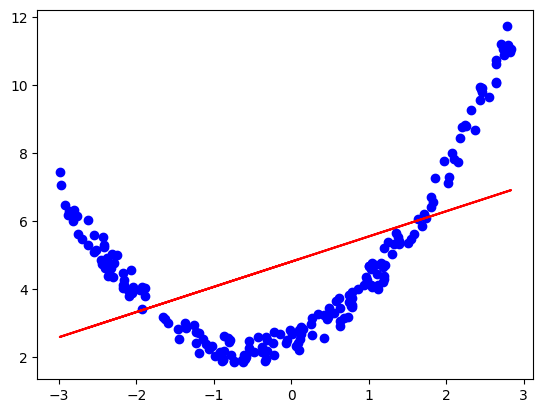

In [10]:
plt.scatter(x, y, color = 'b')
plt.plot(xtrain, lr.predict(xtrain), color = 'r')

In [15]:
poly = PolynomialFeatures(degree=50)
poly_xtrain = poly.fit_transform(xtrain)
poly_xtest = poly.transform(xtest)

lr = LinearRegression()
lr.fit(poly_xtrain, ytrain)
lrp = lr.predict(poly_xtest)

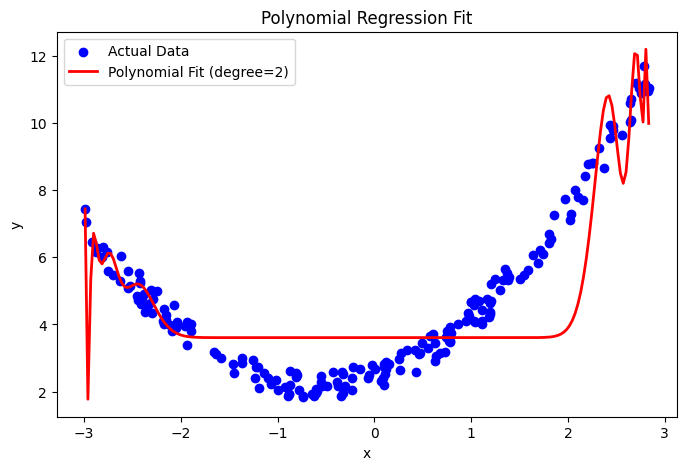

In [16]:
# 1. Create a dense, sorted sequence of X values
X_new = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)

# 2. Transform the new points into polynomial features
X_new_poly = poly.transform(X_new)

# 3. Predict y values using the trained polynomial model
y_new_pred = lr.predict(X_new_poly)

# 4. Plot original data and the polynomial curve
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(X_new, y_new_pred, color='red', linewidth=2, label='Polynomial Fit (degree=2)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()